# A Star - Navigation 

## Setup
Install required dependencies for interactive widgets

In [16]:
!pip install ipywidgets --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
from matplotlib import animation
from IPython.display import HTML, display, clear_output
import ipywidgets as widgets

In [ ]:
# Configeration
class Config:
    def __init__(self):
        self.grid_size = 0.5  # Grid cell size in meters
        self.robot_radius = 0.5  # Robot collision radius
        self.max_x = 12.0  # Grid maximum x
        self.max_y = 12.0  # Grid max height

cfg = Config()

In [19]:
def pos_to_grid(x, y, cfg):
    """Convert continuous position to grid coordinates"""
    return int(x / cfg.grid_size), int(y / cfg.grid_size)

def grid_to_pos(gx, gy, cfg):
    """Convert grid coordinates to continuous position"""
    return gx * cfg.grid_size + cfg.grid_size / 2, gy * cfg.grid_size + cfg.grid_size / 2

def heuristic(gx, gy, goal_x, goal_y):
    """Euclidean heuristic for A*"""
    return math.hypot(gx - goal_x, gy - goal_y)

## A* Algorithm


In [ ]:
import heapq

class Node:
    def __init__(self, x, y, g_cost, h_cost, parent=None):
        self.x = x
        self.y = y
        self.g_cost = g_cost  # Inital cost
        self.h_cost = h_cost  # Heuristic cost to goal
        self.f_cost = g_cost + h_cost  # Total 
        self.parent = parent

    def __lt__(self, other):
        return self.f_cost < other.f_cost

def get_neighbors(x, y):
    """Get valid neighboring cells (8-directional)"""
    neighbors = []
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            neighbors.append((x + dx, y + dy))
    return neighbors

def distance_to_line_segment(px, py, x1, y1, x2, y2):
    """Calculate distance from point to line segment"""
    dx = x2 - x1
    dy = y2 - y1

    if dx == 0 and dy == 0:
        return math.hypot(px - x1, py - y1)

    t = max(0, min(1, ((px - x1) * dx + (py - y1) * dy) / (dx * dx + dy * dy)))
    closest_x = x1 + t * dx
    closest_y = y1 + t * dy

    return math.hypot(px - closest_x, py - closest_y)

def is_collision(gx, gy, obstacles, cfg, walls=None):
    """Check if grid cell collides with obstacles or walls"""
    x, y = grid_to_pos(gx, gy, cfg)

    # Check for obstacles
    for ox, oy in obstacles:
        dist = math.hypot(x - ox, y - oy)
        if dist < cfg.robot_radius:
            return True

    # Check for walls
    if walls:
        for wall in walls:
            if len(wall) == 4:  # [x1, y1, x2, y2] format
                dist = distance_to_line_segment(x, y, wall[0], wall[1], wall[2], wall[3])
                if dist < cfg.robot_radius:
                    return True

    return False

def a_star(start_x, start_y, goal_x, goal_y, obstacles, cfg, walls=None):
    """A* algorithm to find optimal path"""
    sx, sy = pos_to_grid(start_x, start_y, cfg)
    gx, gy = pos_to_grid(goal_x, goal_y, cfg)

    # Check if start or goal is in collision
    if is_collision(sx, sy, obstacles, cfg, walls) or is_collision(gx, gy, obstacles, cfg, walls):
        return None

    open_list = []
    closed_set = set()
    node_dict = {}

    start_node = Node(sx, sy, 0, heuristic(sx, sy, gx, gy), None)
    heapq.heappush(open_list, (start_node.f_cost, id(start_node), start_node))
    node_dict[(sx, sy)] = start_node

    while open_list:
        _, _, current = heapq.heappop(open_list)

        if (current.x, current.y) in closed_set:
            continue

        closed_set.add((current.x, current.y))

        if current.x == gx and current.y == gy:
            # Reconstruct path
            path = []
            node = current
            while node is not None:
                path.append(grid_to_pos(node.x, node.y, cfg))
                node = node.parent
            return list(reversed(path))

        for nx, ny in get_neighbors(current.x, current.y):
            if (nx, ny) in closed_set:
                continue
            if nx < 0 or ny < 0 or nx >= int(cfg.max_x / cfg.grid_size) or ny >= int(cfg.max_y / cfg.grid_size):
                continue
            if is_collision(nx, ny, obstacles, cfg, walls):
                continue

            move_cost = 1.4 if abs(nx - current.x) == 1 and abs(ny - current.y) == 1 else 1
            new_g_cost = current.g_cost + move_cost

            if (nx, ny) in node_dict and new_g_cost >= node_dict[(nx, ny)].g_cost:
                continue

            h_cost = heuristic(nx, ny, gx, gy)
            new_node = Node(nx, ny, new_g_cost, h_cost, current)
            node_dict[(nx, ny)] = new_node
            heapq.heappush(open_list, (new_node.f_cost, id(new_node), new_node))

    return None

## Visualization


In [21]:
def visualize_path(path, goal, obstacles, walls=None):
    """Visualize the A* path with obstacles, walls, and goal"""
    fig, ax = plt.subplots(figsize=(8, 8))

    if path:
        path_x = [p[0] for p in path]
        path_y = [p[1] for p in path]
        ax.plot(path_x, path_y, 'b-', linewidth=2, label='Path')
        ax.plot(path_x[0], path_y[0], 'go', markersize=10, label='Start')
        ax.plot(path_x[-1], path_y[-1], 'bs', markersize=10, label='End')

    ax.plot(goal[0], goal[1], 'r*', markersize=15, label='Goal')
    if len(obstacles) > 0:
        ax.plot(*zip(*obstacles), 'ko', markersize=8, label='Obstacles')

    # Draw walls as thick black lines
    if walls:
        for wall in walls:
            if len(wall) == 4:  # [x1, y1, x2, y2] format
                ax.plot([wall[0], wall[2]], [wall[1], wall[3]], 'k-', linewidth=4, alpha=0.8, label='Walls' if walls.index(wall) == 0 else "")

    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('A* Path Planning')

    return fig

## Simulation
Run A* pathfinding algorithm to find optimal path from start to goal

Path found with 29 waypoints
Path length: 16.90 meters


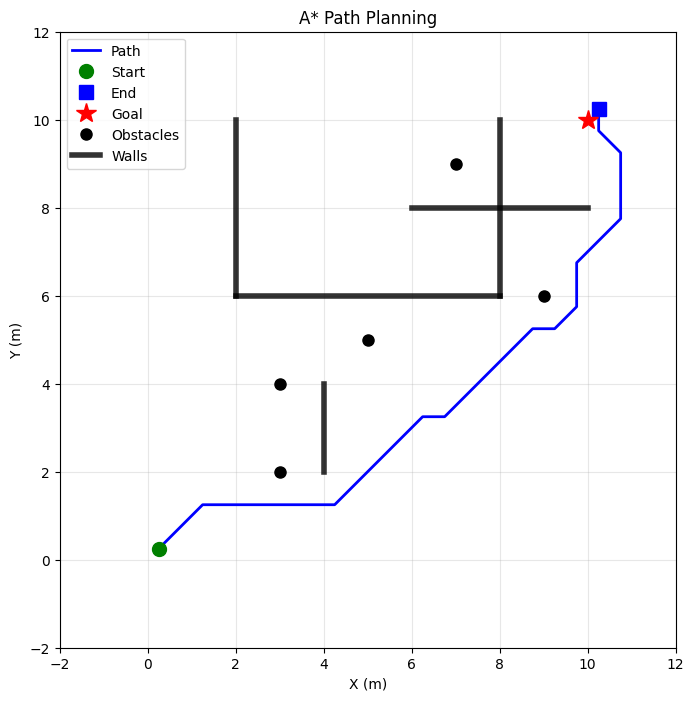

In [ ]:
start_x, start_y = 0.0, 0.0
goal_x, goal_y = 10.0, 10.0
obstacles = np.array([[3, 2], [3, 4], [5, 5], [9, 6], [7, 9]])

walls = [
    [2, 6, 8, 6],   # Horizontal wall
    [2, 6, 2, 10],  # Vertical wall
    [8, 6, 8, 10],  # Vertical wall
    [4, 2, 4, 4],   # Short vertical wall
    [6, 8, 10, 8],  # Horizontal wall
]

path = a_star(start_x, start_y, goal_x, goal_y, obstacles, cfg, walls)

if path:
    print(f"Path found with {len(path)} waypoints")
    print(f"Path length: {sum(math.hypot(path[i+1][0] - path[i][0], path[i+1][1] - path[i][1]) for i in range(len(path)-1)):.2f} meters")
else:
    print("No path found!")

fig = visualize_path(path, [goal_x, goal_y], obstacles, walls)
plt.show()

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

def animate_path(path, goal, obstacles, walls, cfg, interval=100):
    """
    Animate robot movement along the found path.
    
    Parameters:
        path: list of (x, y) waypoints from A*
        goal: (x, y) goal coordinates
        obstacles: list of (x, y) point obstacles
        walls: list of wall segments [x1, y1, x2, y2]
        cfg: config object with robot_radius, grid_size, etc.
        interval: time between frames in milliseconds
    """
    if not path:
        print("No path to animate.")
        return

    fig, ax = plt.subplots(figsize=(8, 8))
    
    ax.plot(goal[0], goal[1], 'r*', markersize=15, label='Goal')
    if len(obstacles) > 0:
        ax.plot(*zip(*obstacles), 'ko', markersize=8, label='Obstacles')
    if walls:
        for wall in walls:
            ax.plot([wall[0], wall[2]], [wall[1], wall[3]], 'k-', linewidth=4, alpha=0.8)
    
    path_x = [p[0] for p in path]
    path_y = [p[1] for p in path]
    ax.plot(path_x, path_y, 'b--', linewidth=1.5, alpha=0.6, label='Planned path')
    
    robot = plt.Circle(path[0], cfg.robot_radius, fc='green', ec='black', alpha=0.7, label='Robot')
    ax.add_patch(robot)
    
    ax.plot(path[0][0], path[0][1], 'go', markersize=10, label='Start')
    
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Robot Movement Animation')
    
    def update(frame):
        x, y = path[frame]
        robot.set_center((x, y))
        if frame == len(path)-1:
            robot.set_fc('blue')
        return robot,
    
    # Create animation
    anim = animation.FuncAnimation(fig, update, frames=len(path), 
                                   interval=interval, repeat=False, blit=True)
    
    plt.close(fig)  
    return anim

## Save and display  
if path:
    anim = animate_path(path, (goal_x, goal_y), obstacles, walls, cfg, interval=150)
    # Use to_jshtml() instead of to_html5_video() – no ffmpeg needed
    from IPython.display import HTML, display
    display(HTML(anim.to_jshtml()))
else:
    print("No path to animate.")